# Reconstruccion de la imagen a partir de la señal del implante

## Objetivo
Entrenar modelos U-Net para reconstruir la imagen original a partir del percepto (visión simulada del implante retinal). Se entrenan dos estrategias:
- **U-Net por implante**: Un modelo independiente para cada implante (Argus2, PRIMA, AlphaMS)
- **U-Net de fusión**: Toma 3 perceptos simultáneamente y genera la reconstrucción

## Proceso
1. Carga perceptos y máscaras originales
2. Define U-Net para segmentación/reconstrucción
3. Busca learning rate óptimo por implante
4. Entrena con validación cruzada
5. Evalúa en test set y visualiza reconstrucciones

In [2]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


### Autenticación Google Drive
Monta Google Drive para acceso a datos compartidos

In [3]:
!pip install -q torch torchvision matplotlib pandas pillow tqdm

### Instalación de dependencias
Instala librerías para deep learning (PyTorch) y procesamiento de datos

In [4]:
from pathlib import Path
import sys

PROJECT_ROOT = Path("/content/drive/MyDrive/tp_final_vision_artificial")
DATA_DIR = PROJECT_ROOT / "data"
MASKS_DIR = DATA_DIR / "masks"
PERCEPTS_DIR = DATA_DIR / "percepts"
METADATA_DIR = DATA_DIR / "metadata"
SRC_DIR = PROJECT_ROOT / "src"

OUTPUTS_DIR = PROJECT_ROOT / "outputs"
MODELS_DIR = OUTPUTS_DIR / "models"
METRICS_DIR = OUTPUTS_DIR / "metrics"
FIGURES_DIR = OUTPUTS_DIR / "figures"

for d in [MODELS_DIR, METRICS_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(PROJECT_ROOT))

print("PROJECT_ROOT:", PROJECT_ROOT)
print("MASKS_DIR:", MASKS_DIR, "| existe:", MASKS_DIR.exists())
print("PERCEPTS_DIR:", PERCEPTS_DIR, "| existe:", PERCEPTS_DIR.exists())
print("METADATA_DIR:", METADATA_DIR, "| existe:", METADATA_DIR.exists())
print("src/reconstruction:", (SRC_DIR / "reconstruction").exists())
print("MODELS_DIR:", MODELS_DIR)
print("METRICS_DIR:", METRICS_DIR)
print("FIGURES_DIR:", FIGURES_DIR)

print("\nn máscaras:", len(list(MASKS_DIR.rglob("*.png"))))
print("n percepts:", len(list(PERCEPTS_DIR.rglob("*.png"))))

PROJECT_ROOT: /content/drive/MyDrive/tp_final_vision_artificial
MASKS_DIR: /content/drive/MyDrive/tp_final_vision_artificial/data/masks | existe: True
PERCEPTS_DIR: /content/drive/MyDrive/tp_final_vision_artificial/data/percepts | existe: True
METADATA_DIR: /content/drive/MyDrive/tp_final_vision_artificial/data/metadata | existe: True
src/reconstruction: True
MODELS_DIR: /content/drive/MyDrive/tp_final_vision_artificial/outputs/models
METRICS_DIR: /content/drive/MyDrive/tp_final_vision_artificial/outputs/metrics
FIGURES_DIR: /content/drive/MyDrive/tp_final_vision_artificial/outputs/figures

n máscaras: 10642
n percepts: 9972


### Setup de rutas y directorios
Define rutas hacia:
- Datos de entrada (percepts, masks, metadata)
- Directorio de modelos guardados
- Directorios de métricas y figuras

In [5]:
import random
import json

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from PIL import Image as PILImage
from IPython.display import display

from torch.utils.data import DataLoader

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


### Inicialización de PyTorch y dispositivo
Configura:
- Reproducibilidad (SEED=42)
- Device (GPU si disponible)
- Importa funciones para entrenamiento de U-Net

In [6]:
from src.classification.datasets import (
    create_sample_split,
    check_split_leakage,
)

from src.reconstruction.datasets import (
    PerceptReconstructionDataset,
    PerceptFusionDataset,
)
from src.reconstruction.models import PerceptUNet
from src.reconstruction.training import (
    fit_reconstruction,
    select_lr_candidate_recon,
)
from src.reconstruction.evaluation import (
    plot_reconstruction_curves,
    evaluate_reconstruction,
)
from src.reconstruction.visualization import (
    visualize_reconstructions,
)

### Importación de módulos de reconstrucción
Carga:
- Dataset loaders para reconstrucción
- Modelo U-Net
- Funciones de entrenamiento y evaluación
- Funciones de visualización

In [7]:
METADATA_PERCEPTS_FILE = METADATA_DIR / "metadata_percepts.csv"

CLASSES = [
    "person",
    "car",
    "chair",
    "dining table",
]

IMPLANTS = [
    "argus2",
    "prima",
    "alphams",
]

RECON_IMG_SIZE = 256
RECON_BATCH_SIZE = 16
RECON_EPOCHS = 30
RECON_LR_CANDIDATES = [1e-4, 3e-4, 1e-3]
RECON_EARLY_STOPPING_PATIENCE = 5
RECON_EARLY_STOPPING_MIN_DELTA = 0.0
RECON_BCE_WEIGHT = 0.5
RECON_MONITOR = "val_dice"

# Si está en False, Run all intenta cargar modelos/resultados existentes.
# Si querés reentrenar desde cero, ponelo en True.
FORCE_RETRAIN = False


def _json_default(obj):
    """Convierte tipos numpy a tipos serializables por JSON."""
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    if isinstance(obj, (np.ndarray,)):
        return obj.tolist()
    return str(obj)


def save_json(obj, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w") as f:
        json.dump(obj, f, indent=2, default=_json_default)


def load_json(path):
    path = Path(path)
    with open(path, "r") as f:
        return json.load(f)


print("Metadata percepts:", METADATA_PERCEPTS_FILE)
print("Existe:", METADATA_PERCEPTS_FILE.exists())
print("FORCE_RETRAIN:", FORCE_RETRAIN)

Metadata percepts: /content/drive/MyDrive/tp_final_vision_artificial/data/metadata/metadata_percepts.csv
Existe: True
FORCE_RETRAIN: False


### Configuración de entrenamiento de U-Net
Parámetros clave:
- **IMG_SIZE**: Tamaño de entrada/salida (256×256)
- **EPOCHS**: Número de épocas de entrenamiento
- **LR_CANDIDATES**: Learning rates a probar
- **BATCH_SIZE**: Tamaño de batch
- **MONITOR**: Métrica a optimizar (val_dice)
- **BCE_WEIGHT**: Ponderación entre pérdida BCE y Dice

In [8]:
df = pd.read_csv(METADATA_PERCEPTS_FILE)


def remap_project_path(p):
    s = str(p)
    p0 = Path(s)
    if p0.exists():
        return s
    marker = "/data/"
    if marker in s:
        return str(PROJECT_ROOT / "data" / s.split(marker, 1)[1])
    if s.startswith("data/"):
        return str(PROJECT_ROOT / s)
    return s


for col in ["percept_path", "signal_path", "mask_path"]:
    if col in df.columns:
        df[col] = df[col].apply(remap_project_path)

n_percepts = df["percept_path"].apply(lambda p: Path(p).exists()).sum()
n_masks = df["mask_path"].apply(lambda p: Path(p).exists()).sum()
print(f"Perceptos existentes: {n_percepts}/{len(df)}")
print(f"Máscaras existentes: {n_masks}/{len(df)}")
print(df.shape)
display(df.head())

print("\nColumnas:")
print(df.columns.tolist())

print("\nDistribución por implante y clase:")
display(
    df.groupby(["implant", "label"])
      .size()
      .reset_index(name="n")
)

Perceptos existentes: 9972/9972
Máscaras existentes: 9972/9972
(9972, 8)


,sample_id,image_id,ann_id,label,implant,mask_path,signal_path,percept_path
0,1000_1304800,1000,1304800,person,alphams,/content/drive/MyDrive/tp_final_vision_artific...,/content/drive/MyDrive/tp_final_vision_artific...,/content/drive/MyDrive/tp_final_vision_artific...
1,1000_1304800,1000,1304800,person,argus2,/content/drive/MyDrive/tp_final_vision_artific...,/content/drive/MyDrive/tp_final_vision_artific...,/content/drive/MyDrive/tp_final_vision_artific...
2,1000_1304800,1000,1304800,person,prima,/content/drive/MyDrive/tp_final_vision_artific...,/content/drive/MyDrive/tp_final_vision_artific...,/content/drive/MyDrive/tp_final_vision_artific...
3,1000_1311471,1000,1311471,person,alphams,/content/drive/MyDrive/tp_final_vision_artific...,/content/drive/MyDrive/tp_final_vision_artific...,/content/drive/MyDrive/tp_final_vision_artific...
4,1000_1311471,1000,1311471,person,argus2,/content/drive/MyDrive/tp_final_vision_artific...,/content/drive/MyDrive/tp_final_vision_artific...,/content/drive/MyDrive/tp_final_vision_artific...



Columnas:
['sample_id', 'image_id', 'ann_id', 'label', 'implant', 'mask_path', 'signal_path', 'percept_path']

Distribución por implante y clase:


,implant,label,n
0,alphams,car,900
1,alphams,chair,900
2,alphams,dining table,624
3,alphams,person,900
4,argus2,car,900
5,argus2,chair,900
6,argus2,dining table,624
7,argus2,person,900
8,prima,car,900
9,prima,chair,900


### Carga y validación de datos
Carga metadatos de perceptos y remapea rutas si es necesario. Valida:
- Que existan todos los archivos de perceptos
- Que existan todas las máscaras originales
- Distribución por implante y clase

In [9]:
df_train, df_val, df_test = create_sample_split(
    df=df,
    test_size=0.15,
    val_size=0.15,
    seed=SEED,
)

print(f"Train rows: {len(df_train):,}")
print(f"Val rows:   {len(df_val):,}")
print(f"Test rows:  {len(df_test):,}")

print("\nSamples únicos:")
print("Train:", df_train["sample_id"].nunique())
print("Val:", df_val["sample_id"].nunique())
print("Test:", df_test["sample_id"].nunique())

check_split_leakage(df_train, df_val, df_test)

Train rows: 6,978
Val rows:   1,497
Test rows:  1,497

Samples únicos:
Train: 2326
Val: 499
Test: 499
Train ∩ Val: 0
Train ∩ Test: 0
Val ∩ Test: 0
Split OK: no hay leakage por sample_id.


### División de datos para reconstrucción
Divide el dataset en:
- **Train (70%)**: Para entrenar U-Net
- **Validation (15%)**: Para seleccionar learning rate
- **Test (15%)**: Para evaluación final
Verifica integridad del split

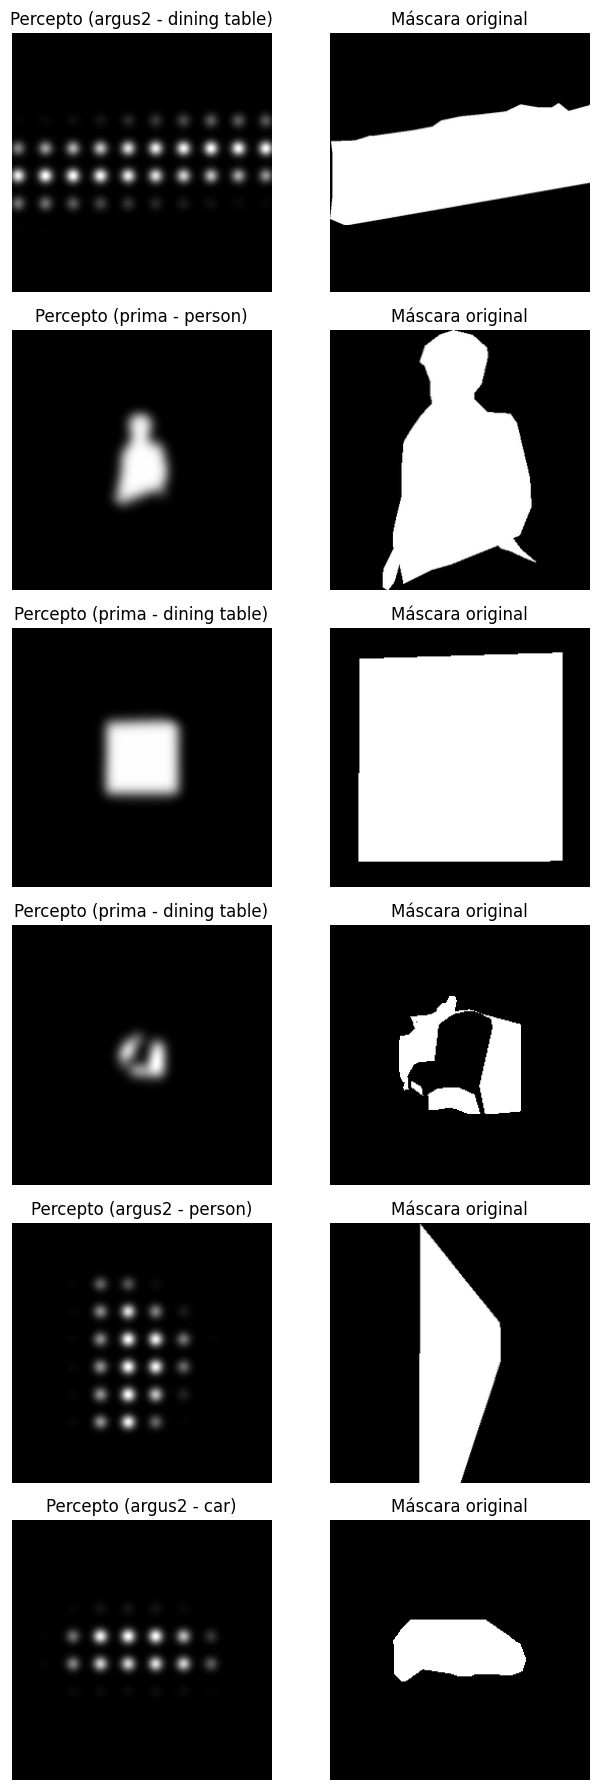

In [10]:
sample = df_train.sample(min(6, len(df_train)), random_state=SEED)

plt.figure(figsize=(7, 3 * len(sample)))
for i, (_, row) in enumerate(sample.iterrows()):
    percept_img = PILImage.open(row["percept_path"]).convert("L")
    mask_img = PILImage.open(row["mask_path"]).convert("L")

    plt.subplot(len(sample), 2, 2 * i + 1)
    plt.imshow(percept_img, cmap="gray")
    plt.title(f"Percepto ({row['implant']} - {row['label']})")
    plt.axis("off")

    plt.subplot(len(sample), 2, 2 * i + 2)
    plt.imshow(mask_img, cmap="gray")
    plt.title("Máscara original")
    plt.axis("off")

plt.tight_layout()
plt.show()

### Visualización de pares percepto-máscara
Muestra ejemplos de pares entrada-salida:
- **Izquierda**: Percepto (entrada del U-Net) - imagen pixelada
- **Derecha**: Máscara original (salida esperada) - imagen binaria clara

Ilustra la tarea de reconstrucción

## Entrenamiento U-Net por implante

In [11]:
histories_recon = {}
models_recon = {}
recon_summary_rows = {}

for implant in IMPLANTS:
    print("\n" + "=" * 70)
    print(f"Reconstrucción U-Net - {implant}")
    print("=" * 70)

    model_path = MODELS_DIR / f"unet_{implant}.pt"
    history_path = METRICS_DIR / f"history_unet_{implant}.json"
    config_path = METRICS_DIR / f"config_unet_{implant}.json"

    if model_path.exists() and not FORCE_RETRAIN:
        print(f"Modelo ya existe. Lo cargo y NO reentreno: {model_path}")

        model = PerceptUNet(in_channels=1).to(DEVICE)
        model.load_state_dict(
            torch.load(model_path, map_location=torch.device(DEVICE))
        )
        model.eval()

        models_recon[implant] = model
        histories_recon[implant] = load_json(history_path) if history_path.exists() else None

        cfg = load_json(config_path) if config_path.exists() else {}
        recon_summary_rows[implant] = {
            "model": f"unet_{implant}",
            "best_lr": cfg.get("best_lr"),
            "best_val_dice": cfg.get("best_val_dice"),
        }

        continue

    print("No encontré modelo previo, o FORCE_RETRAIN=True. Entrenando...")

    df_train_imp = df_train[df_train["implant"] == implant].copy()
    df_val_imp = df_val[df_val["implant"] == implant].copy()

    ds_train = PerceptReconstructionDataset(df_train_imp, img_size=RECON_IMG_SIZE, train=True)
    ds_val = PerceptReconstructionDataset(df_val_imp, img_size=RECON_IMG_SIZE, train=False)

    ld_train = DataLoader(
        ds_train,
        batch_size=RECON_BATCH_SIZE,
        shuffle=True,
        num_workers=2,
        pin_memory=True,
    )
    ld_val = DataLoader(
        ds_val,
        batch_size=RECON_BATCH_SIZE,
        shuffle=False,
        num_workers=2,
        pin_memory=True,
    )

    lr_candidates = []

    for lr in RECON_LR_CANDIDATES:
        print(f"\nLR = {lr}")

        model = PerceptUNet(in_channels=1).to(DEVICE)

        model, hist = fit_reconstruction(
            model=model,
            train_loader=ld_train,
            val_loader=ld_val,
            device=DEVICE,
            epochs=RECON_EPOCHS,
            lr=lr,
            label=f"unet_{implant}_lr{lr}",
            monitor=RECON_MONITOR,
            patience=RECON_EARLY_STOPPING_PATIENCE,
            min_delta=RECON_EARLY_STOPPING_MIN_DELTA,
            bce_weight=RECON_BCE_WEIGHT,
        )

        lr_candidates.append({"lr": lr, "model": model, "history": hist})

    selected, lr_summaries = select_lr_candidate_recon(
        candidates=lr_candidates,
        monitor=RECON_MONITOR,
        prefer_lower_lr=True,
    )

    best_lr = selected["lr"]
    best_dice = selected["best_val_metric"]
    best_hist = selected["history"]
    best_model = selected["model"]

    df_lr_summaries = pd.DataFrame(lr_summaries)
    display(df_lr_summaries)
    df_lr_summaries.to_csv(METRICS_DIR / f"lr_search_unet_{implant}.csv", index=False)

    histories_recon[implant] = best_hist
    models_recon[implant] = best_model
    recon_summary_rows[implant] = {
        "model": f"unet_{implant}",
        "best_lr": best_lr,
        "best_val_dice": best_dice,
    }

    print(f"\nMejor LR para {implant}: {best_lr}")
    print(f"Mejor val dice: {best_dice:.4f}")

    torch.save(best_model.state_dict(), model_path)
    save_json(best_hist, history_path)

    save_json(
        {
            "model": f"unet_{implant}",
            "implant": implant,
            "best_lr": best_lr,
            "best_val_dice": best_dice,
            "epochs": RECON_EPOCHS,
            "batch_size": RECON_BATCH_SIZE,
            "img_size": RECON_IMG_SIZE,
            "bce_weight": RECON_BCE_WEIGHT,
            "classes": CLASSES,
            "lr_candidates": RECON_LR_CANDIDATES,
            "early_stopping": {
                "monitor": RECON_MONITOR,
                "patience": RECON_EARLY_STOPPING_PATIENCE,
                "min_delta": RECON_EARLY_STOPPING_MIN_DELTA,
            },
            "lr_search_csv": str(METRICS_DIR / f"lr_search_unet_{implant}.csv"),
        },
        config_path,
    )


Reconstrucción U-Net - argus2
Modelo ya existe. Lo cargo y NO reentreno: /content/drive/MyDrive/tp_final_vision_artificial/outputs/models/unet_argus2.pt

Reconstrucción U-Net - prima
Modelo ya existe. Lo cargo y NO reentreno: /content/drive/MyDrive/tp_final_vision_artificial/outputs/models/unet_prima.pt

Reconstrucción U-Net - alphams
Modelo ya existe. Lo cargo y NO reentreno: /content/drive/MyDrive/tp_final_vision_artificial/outputs/models/unet_alphams.pt


### Entrenamiento de U-Net por implante
Para cada implante (Argus2, PRIMA, AlphaMS):
1. Busca el mejor learning rate
2. Entrena U-Net con datasets específicos del implante
3. Usa Dice Score como métrica principal
4. Early stopping si no mejora
5. Guarda modelo y métricas

## Entrenamiento de U-Net de fusion

In [12]:
fusion_path = MODELS_DIR / "unet_fusion.pt"
fusion_history_path = METRICS_DIR / "history_unet_fusion.json"
fusion_config_path = METRICS_DIR / "config_unet_fusion.json"

if fusion_path.exists() and not FORCE_RETRAIN:
    print(f"Modelo de fusión ya existe. Lo cargo y NO reentreno: {fusion_path}")

    model_fusion = PerceptUNet(in_channels=len(IMPLANTS)).to(DEVICE)
    model_fusion.load_state_dict(
        torch.load(fusion_path, map_location=torch.device(DEVICE))
    )
    model_fusion.eval()

    history_fusion = load_json(fusion_history_path) if fusion_history_path.exists() else None
    cfg_fusion = load_json(fusion_config_path) if fusion_config_path.exists() else {}
    best_lr_fusion = cfg_fusion.get("best_lr")
    best_dice_fusion = cfg_fusion.get("best_val_dice")

else:
    print("No encontré modelo de fusión previo, o FORCE_RETRAIN=True. Entrenando...")

    ds_fusion_train = PerceptFusionDataset(df_train, implants=IMPLANTS, img_size=RECON_IMG_SIZE, train=True)
    ds_fusion_val = PerceptFusionDataset(df_val, implants=IMPLANTS, img_size=RECON_IMG_SIZE, train=False)

    ld_fusion_train = DataLoader(
        ds_fusion_train,
        batch_size=RECON_BATCH_SIZE,
        shuffle=True,
        num_workers=2,
        pin_memory=True,
    )
    ld_fusion_val = DataLoader(
        ds_fusion_val,
        batch_size=RECON_BATCH_SIZE,
        shuffle=False,
        num_workers=2,
        pin_memory=True,
    )

    lr_candidates_fusion = []

    for lr in RECON_LR_CANDIDATES:
        print(f"\nFusión LR = {lr}")

        model = PerceptUNet(in_channels=len(IMPLANTS)).to(DEVICE)

        model, hist = fit_reconstruction(
            model=model,
            train_loader=ld_fusion_train,
            val_loader=ld_fusion_val,
            device=DEVICE,
            epochs=RECON_EPOCHS,
            lr=lr,
            label=f"unet_fusion_lr{lr}",
            monitor=RECON_MONITOR,
            patience=RECON_EARLY_STOPPING_PATIENCE,
            min_delta=RECON_EARLY_STOPPING_MIN_DELTA,
            bce_weight=RECON_BCE_WEIGHT,
        )

        lr_candidates_fusion.append({"lr": lr, "model": model, "history": hist})

    selected_fusion, lr_summaries_fusion = select_lr_candidate_recon(
        candidates=lr_candidates_fusion,
        monitor=RECON_MONITOR,
        prefer_lower_lr=True,
    )

    best_lr_fusion = selected_fusion["lr"]
    best_dice_fusion = selected_fusion["best_val_metric"]
    history_fusion = selected_fusion["history"]
    model_fusion = selected_fusion["model"]

    df_lr_summaries_fusion = pd.DataFrame(lr_summaries_fusion)
    display(df_lr_summaries_fusion)
    df_lr_summaries_fusion.to_csv(METRICS_DIR / "lr_search_unet_fusion.csv", index=False)

    print(f"\nMejor LR fusión: {best_lr_fusion}")
    print(f"Mejor val dice fusión: {best_dice_fusion:.4f}")

    torch.save(model_fusion.state_dict(), fusion_path)
    save_json(history_fusion, fusion_history_path)

    save_json(
        {
            "model": "unet_fusion",
            "implants": IMPLANTS,
            "best_lr": best_lr_fusion,
            "best_val_dice": best_dice_fusion,
            "epochs": RECON_EPOCHS,
            "batch_size": RECON_BATCH_SIZE,
            "img_size": RECON_IMG_SIZE,
            "bce_weight": RECON_BCE_WEIGHT,
            "classes": CLASSES,
            "lr_candidates": RECON_LR_CANDIDATES,
            "early_stopping": {
                "monitor": RECON_MONITOR,
                "patience": RECON_EARLY_STOPPING_PATIENCE,
                "min_delta": RECON_EARLY_STOPPING_MIN_DELTA,
            },
            "lr_search_csv": str(METRICS_DIR / "lr_search_unet_fusion.csv"),
        },
        fusion_config_path,
    )

No encontré modelo de fusión previo, o FORCE_RETRAIN=True. Entrenando...

Fusión LR = 0.0001
[unet_fusion_lr0.0001] epoch 01/30 train_loss=0.5889 val_loss=0.5852 val_dice=0.3163 val_iou=0.5784 (2954.0s)
[unet_fusion_lr0.0001] epoch 02/30 train_loss=0.5055 val_loss=0.4729 val_dice=0.3577 val_iou=0.7277 (58.2s)
[unet_fusion_lr0.0001] epoch 03/30 train_loss=0.4672 val_loss=0.4555 val_dice=0.3815 val_iou=0.6716 (60.1s)
[unet_fusion_lr0.0001] epoch 04/30 train_loss=0.4348 val_loss=0.4049 val_dice=0.4131 val_iou=0.7706 (58.6s)
[unet_fusion_lr0.0001] epoch 05/30 train_loss=0.4034 val_loss=0.3704 val_dice=0.4440 val_iou=0.7662 (59.7s)
[unet_fusion_lr0.0001] epoch 06/30 train_loss=0.3743 val_loss=0.3401 val_dice=0.4746 val_iou=0.8168 (59.7s)
[unet_fusion_lr0.0001] epoch 07/30 train_loss=0.3469 val_loss=0.3529 val_dice=0.4655 val_iou=0.7961 (60.4s)
[unet_fusion_lr0.0001] epoch 08/30 train_loss=0.3216 val_loss=0.3048 val_dice=0.5190 val_iou=0.8190 (59.9s)
[unet_fusion_lr0.0001] epoch 09/30 train_

,lr,best_val_dice
0,0.0001,0.905238
1,0.0003,0.903123
2,0.0010,0.884760



Mejor LR fusión: 0.0001
Mejor val dice fusión: 0.9052


### U-Net de fusión multi-implante
Entrena un U-Net que:
1. Toma 3 canales de entrada (perceptos de 3 implantes)
2. Genera una reconstrucción única combinando información
3. Busca si la fusión mejora respecto a modelos individuales
4. Guarda configuración y resultados

## Evaluacion de U-Net por implante


Evaluación test - Reconstrucción argus2


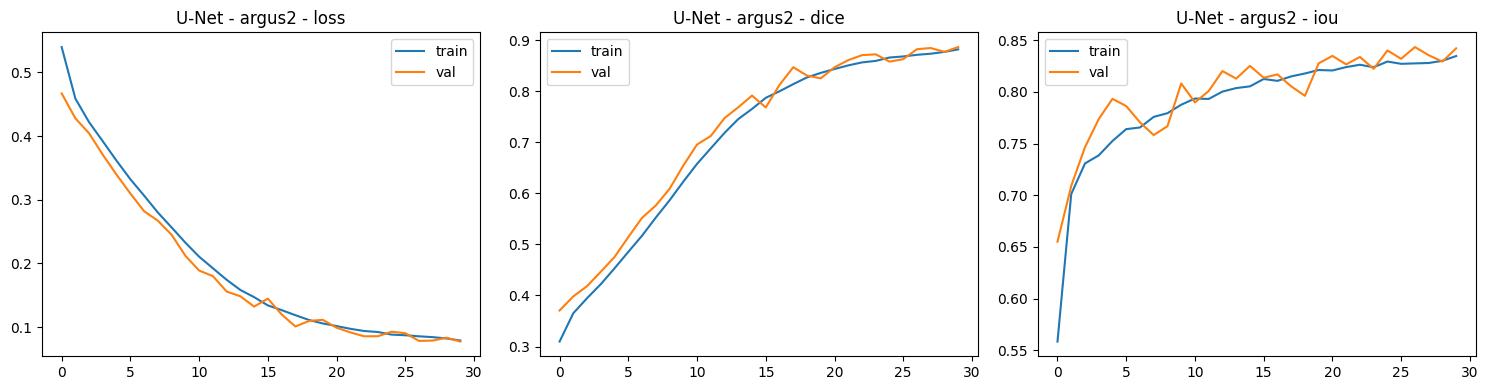

Test metrics: {'dice': 0.8829739298671484, 'iou': 0.8351467233151197, 'pixel_acc': 0.985632698982954}


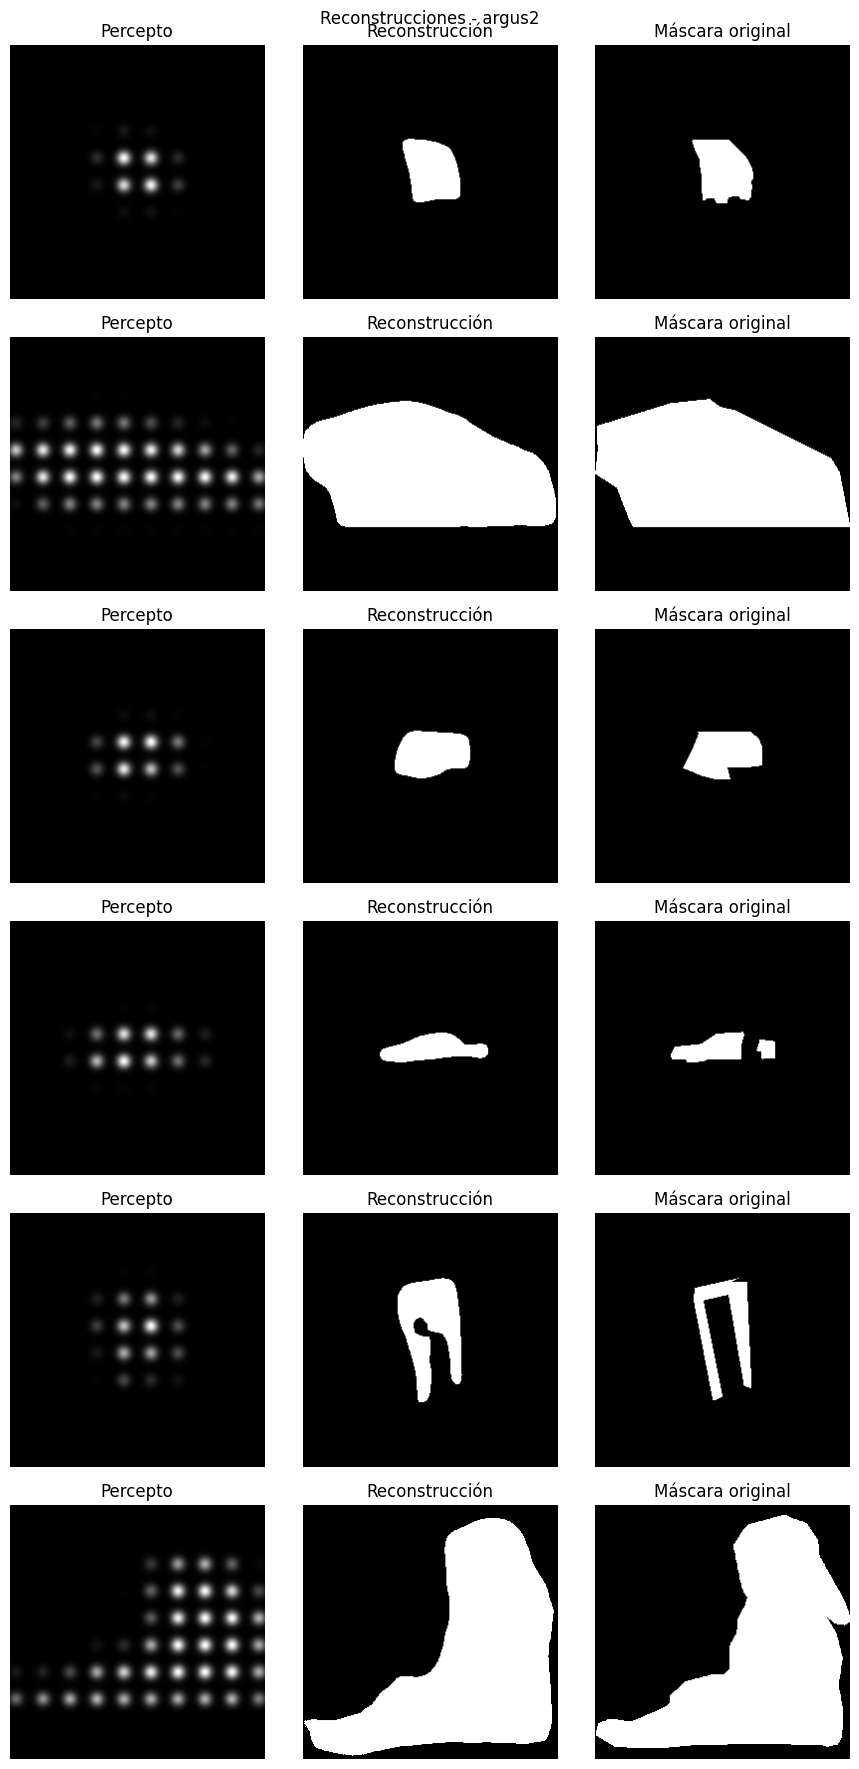


Evaluación test - Reconstrucción prima


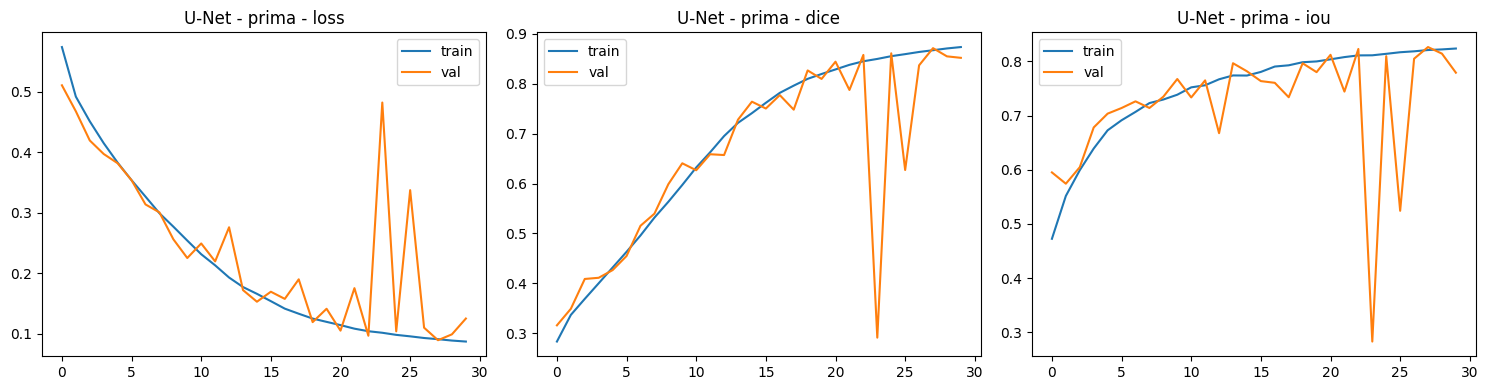

Test metrics: {'dice': 0.871076975017786, 'iou': 0.8245652467012405, 'pixel_acc': 0.9817159380763769}


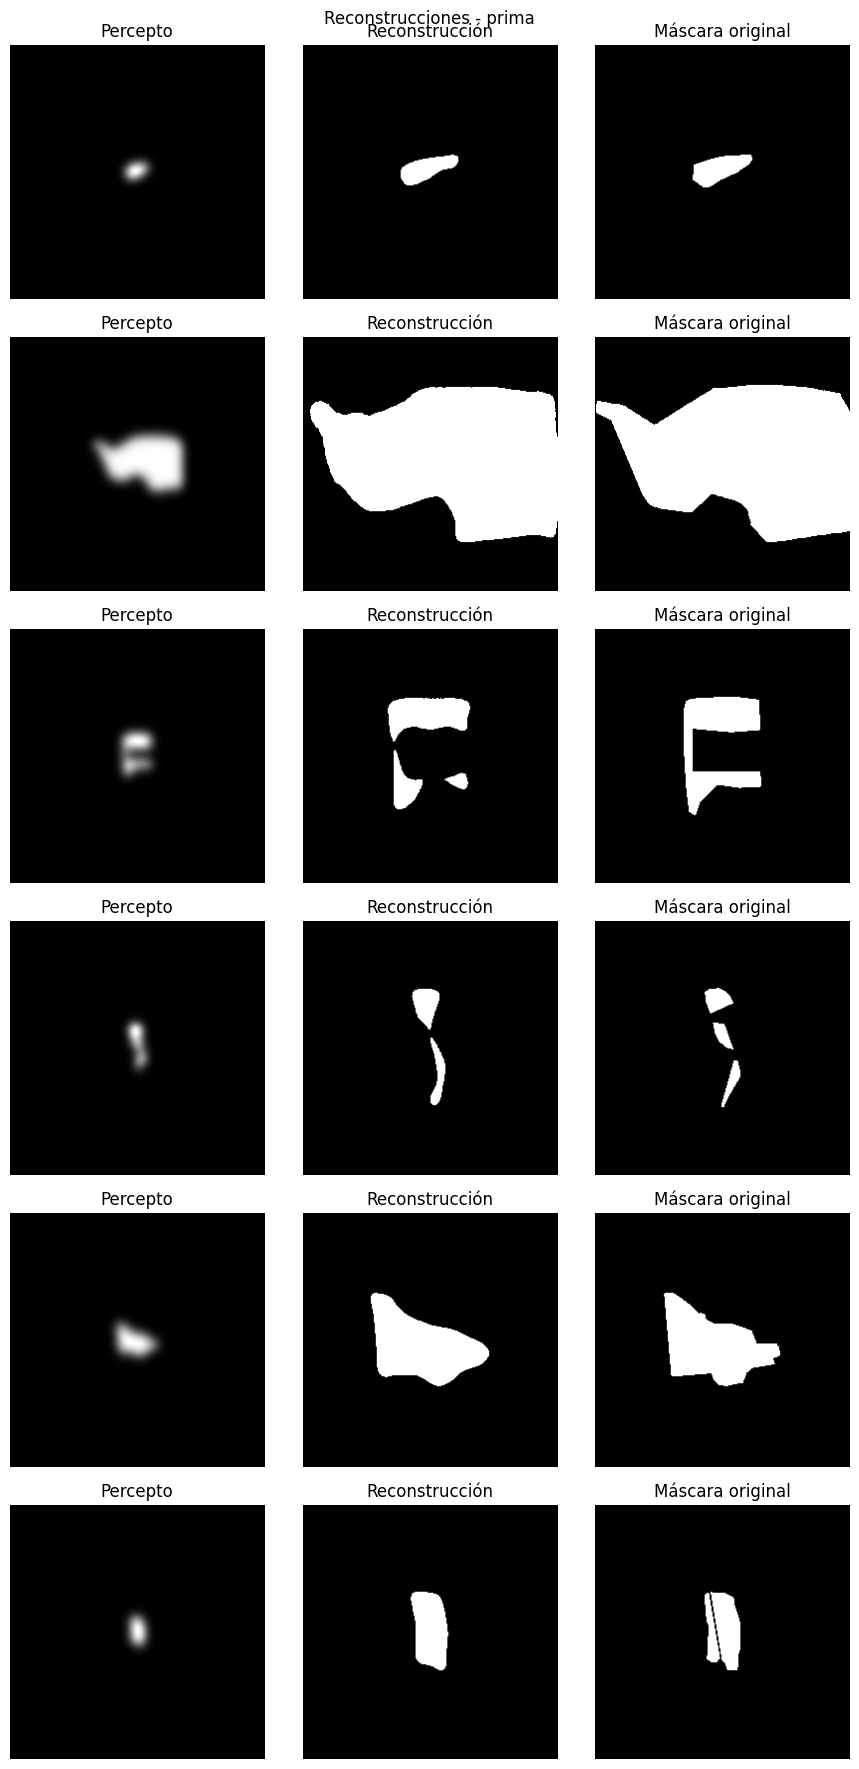


Evaluación test - Reconstrucción alphams


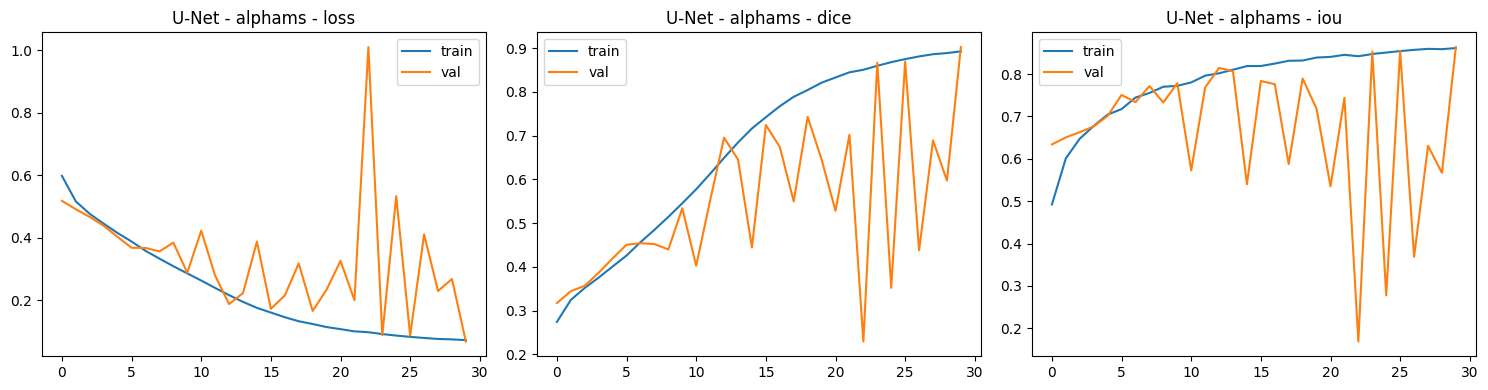

Test metrics: {'dice': 0.9018535744398832, 'iou': 0.8623446933925152, 'pixel_acc': 0.9862819612026215}


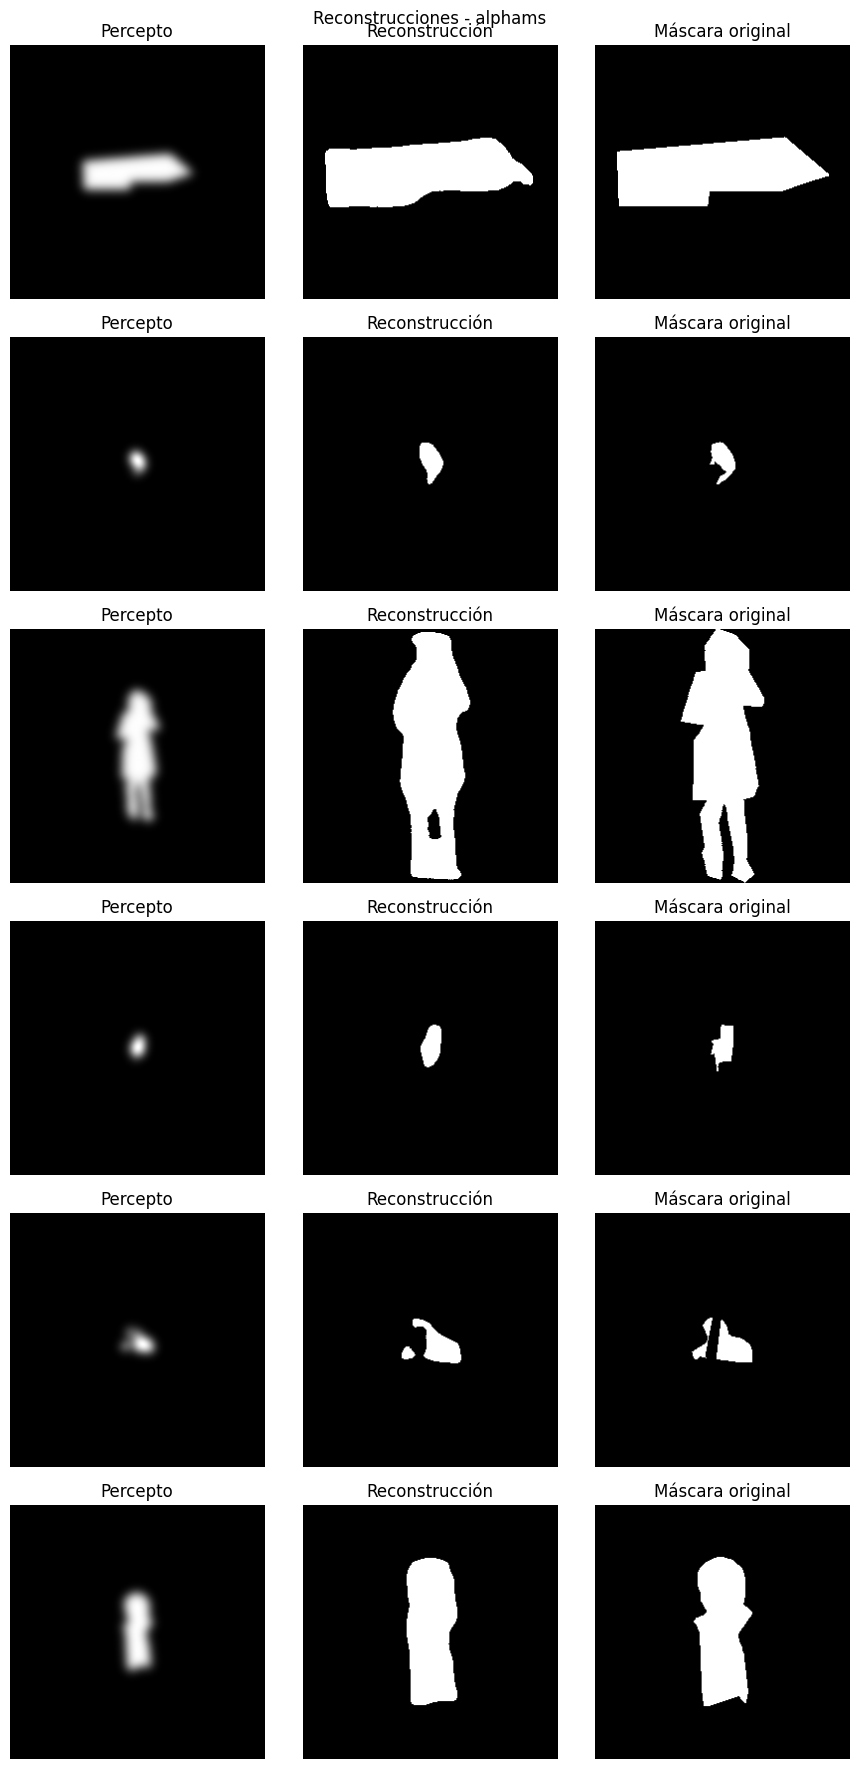

In [13]:
recon_test_summary_rows = []

for implant in IMPLANTS:
    print("\n" + "=" * 70)
    print(f"Evaluación test - Reconstrucción {implant}")
    print("=" * 70)

    if histories_recon.get(implant) is not None:
        plot_reconstruction_curves(
            histories_recon[implant],
            title=f"U-Net - {implant}",
            save_path=FIGURES_DIR / f"training_curves_unet_{implant}.png",
        )
    else:
        print(f"No hay historial para {implant}. Salteo curvas de entrenamiento.")

    df_test_imp = df_test[df_test["implant"] == implant].copy()
    ds_test = PerceptReconstructionDataset(df_test_imp, img_size=RECON_IMG_SIZE, train=False)
    ld_test = DataLoader(
        ds_test,
        batch_size=RECON_BATCH_SIZE,
        shuffle=False,
        num_workers=2,
        pin_memory=True,
    )

    metrics = evaluate_reconstruction(models_recon[implant], ld_test, DEVICE)
    print("Test metrics:", metrics)

    visualize_reconstructions(
        models_recon[implant],
        ds_test,
        DEVICE,
        n_samples=6,
        save_path=FIGURES_DIR / f"reconstructions_{implant}.png",
        title=f"Reconstrucciones - {implant}",
    )

    recon_summary_rows[implant]["test_dice"] = metrics["dice"]
    recon_summary_rows[implant]["test_iou"] = metrics["iou"]
    recon_summary_rows[implant]["test_pixel_acc"] = metrics["pixel_acc"]

    recon_test_summary_rows.append({"model": f"unet_{implant}", **metrics})

### Evaluación en conjunto de test
Evalúa cada U-Net en el conjunto de test:
1. Genera predicciones para todos los test samples
2. Calcula métricas: Dice Score, Jaccard, Accuracy
3. Plotea curvas de entrenamiento (pérdida y Dice)
4. Guarda reportes de métricas

## Evaluacion de U-Net de fusion


Evaluación test - Reconstrucción fusión


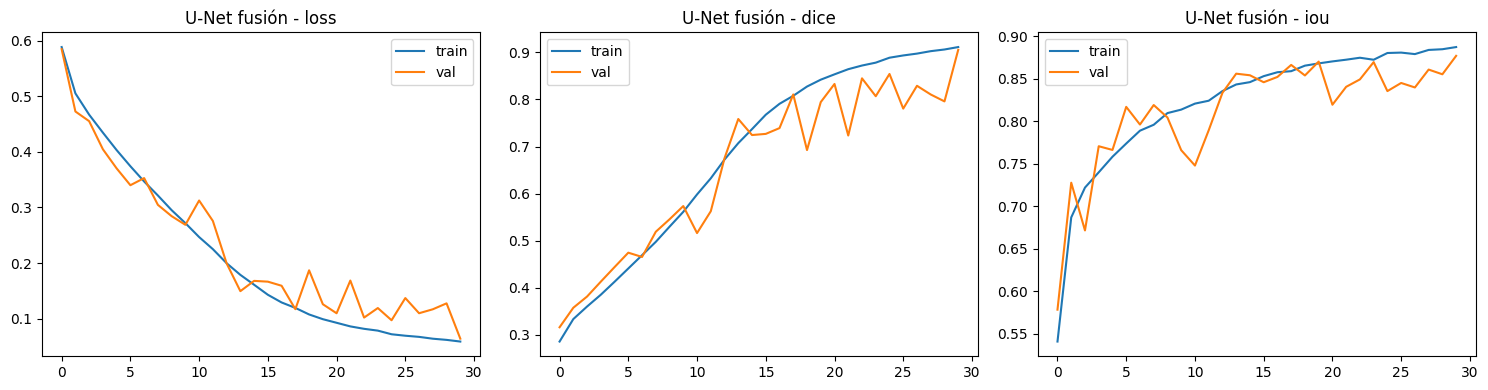

Test metrics fusión: {'dice': 0.9048142377287149, 'iou': 0.8756442163139582, 'pixel_acc': 0.9890595972537994}


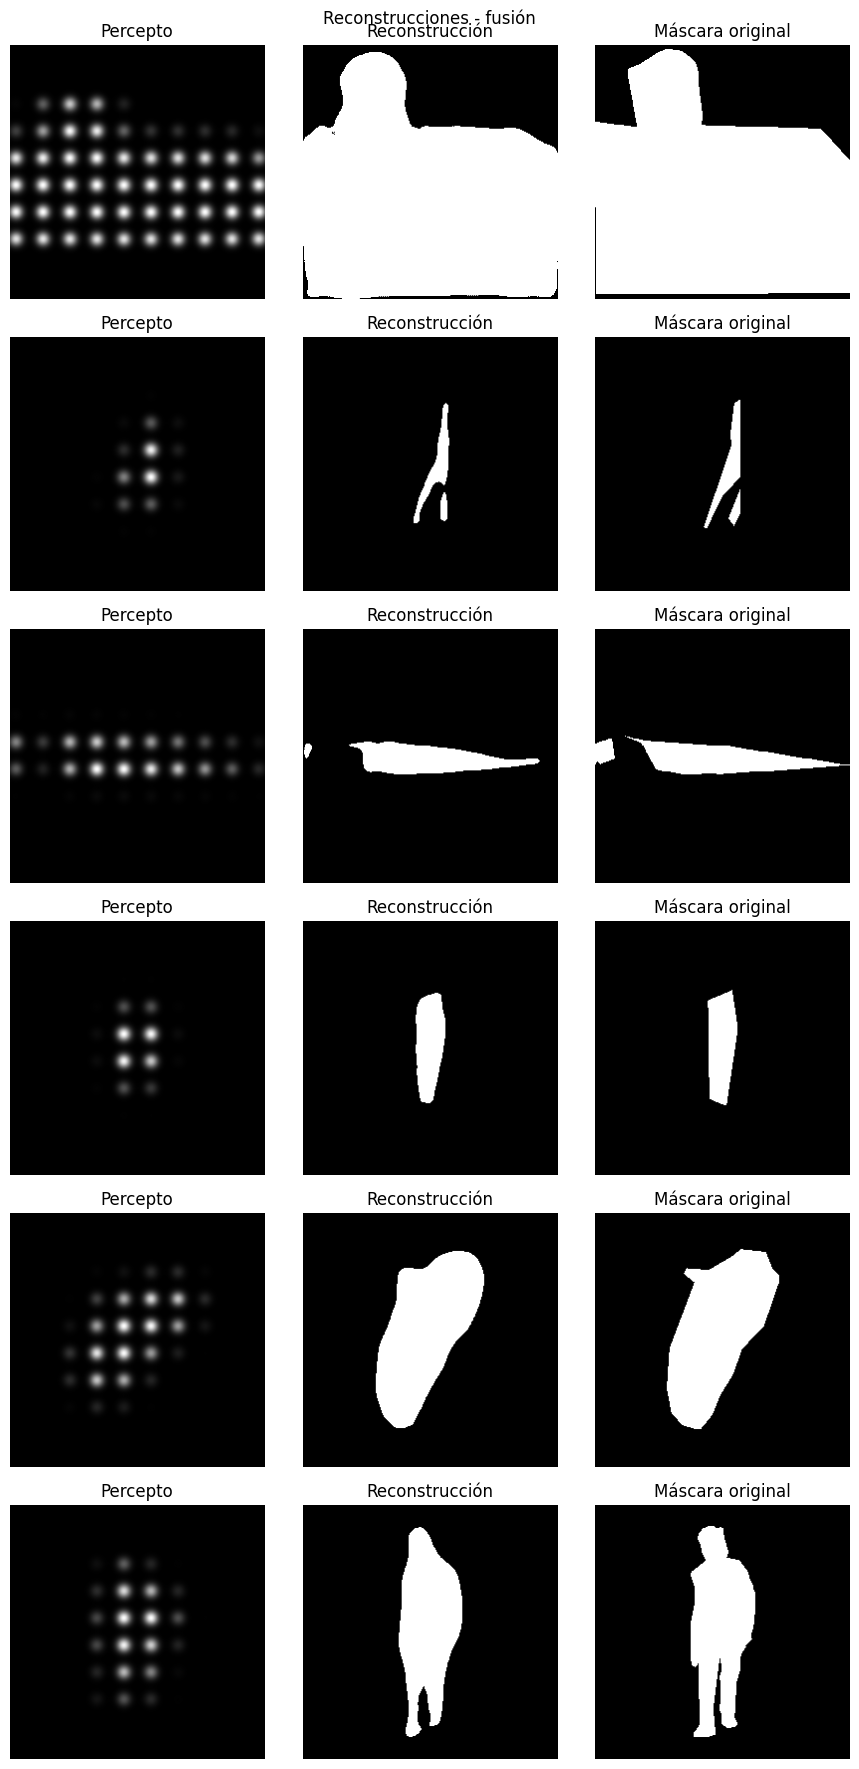

,model,dice,iou,pixel_acc
0,unet_argus2,0.882974,0.835147,0.985633
1,unet_prima,0.871077,0.824565,0.981716
2,unet_alphams,0.901854,0.862345,0.986282
3,unet_fusion,0.904814,0.875644,0.989060


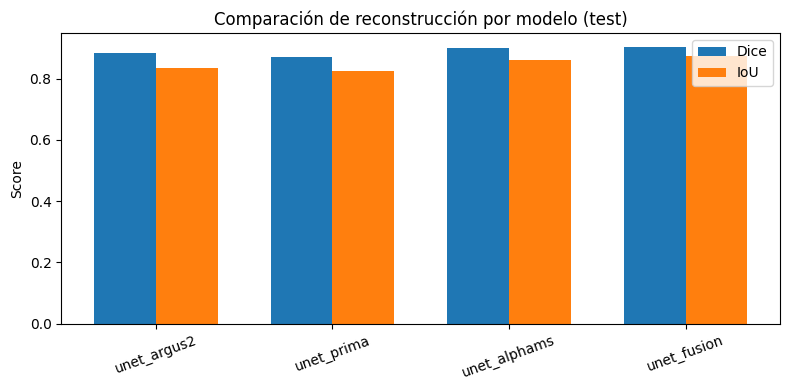

In [14]:
print("\n" + "=" * 70)
print("Evaluación test - Reconstrucción fusión")
print("=" * 70)

if history_fusion is not None:
    plot_reconstruction_curves(
        history_fusion,
        title="U-Net fusión",
        save_path=FIGURES_DIR / "training_curves_unet_fusion.png",
    )
else:
    print("No hay historial de fusión. Salteo curvas de entrenamiento.")

ds_fusion_test = PerceptFusionDataset(df_test, implants=IMPLANTS, img_size=RECON_IMG_SIZE, train=False)
ld_fusion_test = DataLoader(
    ds_fusion_test,
    batch_size=RECON_BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)

metrics_fusion = evaluate_reconstruction(model_fusion, ld_fusion_test, DEVICE)
print("Test metrics fusión:", metrics_fusion)

visualize_reconstructions(
    model_fusion,
    ds_fusion_test,
    DEVICE,
    n_samples=6,
    save_path=FIGURES_DIR / "reconstructions_fusion.png",
    title="Reconstrucciones - fusión",
)

recon_test_summary_rows.append({"model": "unet_fusion", **metrics_fusion})

df_recon_summary = pd.DataFrame(recon_test_summary_rows)
display(df_recon_summary)
df_recon_summary.to_csv(METRICS_DIR / "summary_reconstruction_results.csv", index=False)

# gráfico comparativo dice/iou por modelo
plt.figure(figsize=(8, 4))
x = np.arange(len(df_recon_summary))
width = 0.35
plt.bar(x - width / 2, df_recon_summary["dice"], width, label="Dice")
plt.bar(x + width / 2, df_recon_summary["iou"], width, label="IoU")
plt.xticks(x, df_recon_summary["model"], rotation=20)
plt.ylabel("Score")
plt.title("Comparación de reconstrucción por modelo (test)")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "comparison_reconstruction_models.png", dpi=120)
plt.show()

### Visualización de reconstrucciones
Muestra ejemplos de reconstrucciones del U-Net:
- Percepto (entrada pixelada)
- Predicción del modelo
- Máscara original (ground truth)

Visualiza qué tan bien el modelo recupera la forma original

In [15]:
print("Modelos:")
!find "{MODELS_DIR}" -maxdepth 2 -type f

print("\nMétricas:")
!find "{METRICS_DIR}" -maxdepth 2 -type f

print("\nFiguras:")
!find "{FIGURES_DIR}" -maxdepth 2 -type f

Modelos:
/content/drive/MyDrive/tp_final_vision_artificial/outputs/models/cnn_baseline_alphams.pt
/content/drive/MyDrive/tp_final_vision_artificial/outputs/models/cnn_baseline_argus2.pt
/content/drive/MyDrive/tp_final_vision_artificial/outputs/models/cnn_baseline_prima.pt
/content/drive/MyDrive/tp_final_vision_artificial/outputs/models/cnn_gru.pt
/content/drive/MyDrive/tp_final_vision_artificial/outputs/models/knn_alphams.joblib
/content/drive/MyDrive/tp_final_vision_artificial/outputs/models/knn_argus2.joblib
/content/drive/MyDrive/tp_final_vision_artificial/outputs/models/knn_multi_implant.joblib
/content/drive/MyDrive/tp_final_vision_artificial/outputs/models/knn_prima.joblib
/content/drive/MyDrive/tp_final_vision_artificial/outputs/models/unet_argus2.pt
/content/drive/MyDrive/tp_final_vision_artificial/outputs/models/unet_prima.pt
/content/drive/MyDrive/tp_final_vision_artificial/outputs/models/unet_alphams.pt
/content/drive/MyDrive/tp_final_vision_artificial/outputs/models/unet_fu